# Beyond BLAST

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [2]:
using Base.Threads

In [3]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

Main.blast_tutorials

In [4]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Dates
using TOML
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using CSV
using DataFrames
using .Blast
using .blast_tutorials;

### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [5]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

### Getting N5K quantities:

In [6]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
z_n5k = sort(z_n5k) # sort the redshift array in ascending order
n_z_matrix = n5k_bins["dNdz_cl"];

### Plotting the dN/dz distribution for each bin:

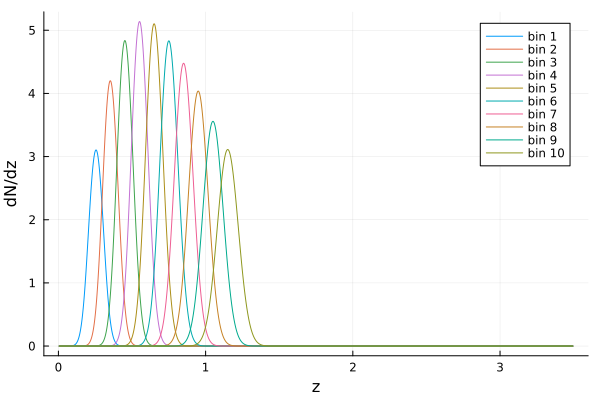

In [7]:
p = plot()
bin = size(n_z_matrix, 2)
for i in 1:bin
    plot!(p, z_n5k, n_z_matrix[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
display(p)

### Normalizing n(z)

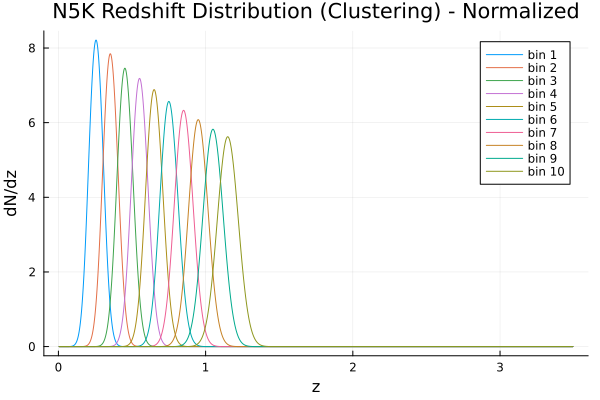

In [8]:
norms = [quadgk(x -> DataInterpolations.AkimaInterpolation(n_z_matrix[:, i], z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                minimum(z_n5k), maximum(z_n5k))[1] for i in 1:bin]
n_z_norm = n_z_matrix ./ reshape(norms, 1, :);

#### PLOTTING the results
p = plot()
for i in 1:size(n_z_norm, 2)
    plot!(p, z_n5k, n_z_norm[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
title!(p, "N5K Redshift Distribution (Clustering) - Normalized")
display(p)

Dimension of total dN/dz: (2000,)
Dimension of normalized total dN/dz: (2000,)


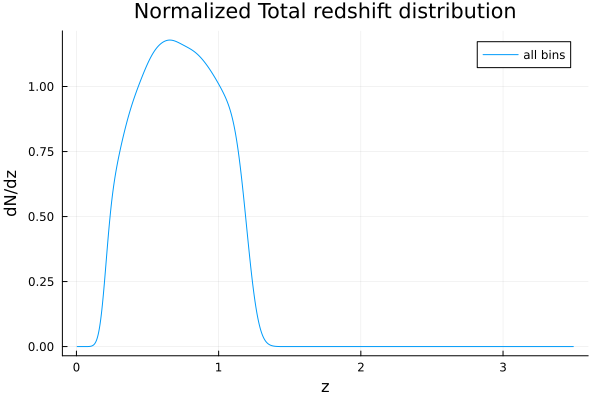

In [9]:
dNdz_tot = sum(n_z_matrix, dims = 2)[:, 1]
#plot(z_n5k, dNdz_tot, label = "all bins", xlabel = "z", ylabel = "dN/dz", title = "Total redshift distribution")
println("Dimension of total dN/dz: $(size(dNdz_tot))")
dNdz_tot_norm = dNdz_tot ./ quadgk(x -> DataInterpolations.AkimaInterpolation(dNdz_tot, z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                                   minimum(z_n5k), maximum(z_n5k))[1]
println("Dimension of normalized total dN/dz: $(size(dNdz_tot_norm))")
plot(z_n5k, dNdz_tot_norm, label = "all bins", xlabel = "z", ylabel = "dN/dz", title = "Normalized Total redshift distribution")

### Creating redshift array and comoving distance array for N5K data

In [10]:
### REDSHIFT ARRAY
z_array = LinRange(minimum(z_n5k), maximum(z_n5k), size(z_n5k)[1]) # array of redshifts to evaluate n(z) on
#### COMOVING DISTANCES ARRAY
chi_array = chi_of_z.(z_array); # array of comoving distances corresponding to z_range

### Setting number of COMOVING DISTANCE POINTS

In [11]:
cosmo = Blast.FlatΛCDM()
n_chi = 100;                  # Number of comoving distance points

### Defining redshift array and comoving distance array with our $\chi_{min}$ and $\chi_{max}$

In [12]:
# Array of comoving distances
x_array = LinRange(26, 7000, n_chi)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(x_array);

### BIAS

In [13]:
###### BIAS ######
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = zeros(size(z_range))
b_z_array = b_0 .* sqrt.(1 .+ z_range); # bias as a function of redshift

### GROWTH FACTOR

In [14]:
###### GROWTH FACTOR ######
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_range)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_range]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_range);

### HUBBLE FACTOR

In [15]:
cosmo = Blast.FlatΛCDM()
import PhysicalConstants.CODATA2018: c_0
const C_LIGHT = c_0.val * 10^(-3) #speed of light in Km/s
inv_Hubble_array = C_LIGHT ./ Blast.compute_hubble_factor.(z_range, Ref(cosmo));

### PLOTTING BIAS $b(z)$, COMOVING DISTANCE $\chi(z)$, and GROWTH FACTOR $D(z)$

### GETTING $n(z)$

the shape of $n(z)$ is taken from [this paper](https://www.aanda.org/articles/aa/pdf/2020/11/aa38313-20.pdf)

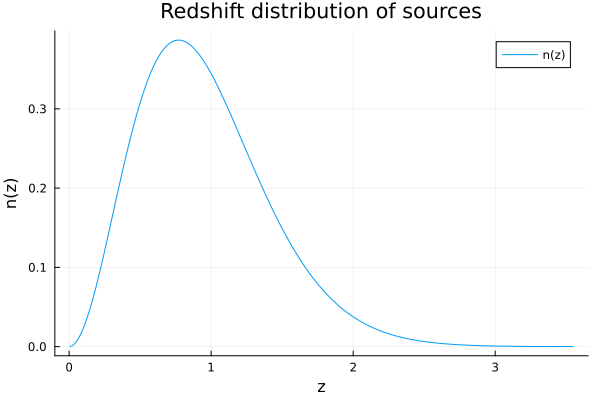

In [16]:
z_0 = 0.9/sqrt(2)
alpha = 2
beta = 1.5
nz = (z_range / z_0).^alpha .* exp.(-(z_range / z_0).^beta) # redshift distribution of sources, normalized to 1
nz_norm = nz ./ quadgk(x -> DataInterpolations.AkimaInterpolation(nz, z_range, extrapolation=ExtrapolationType.Linear)(x),
                   minimum(z_range), maximum(z_range))[1]
plot(z_range, nz, label="n(z)", xlabel="z", ylabel="n(z)", title="Redshift distribution of sources")

In [17]:
# n_0 = 141.5*1e-4 # in units of h^3 Mpc^-3
# r_0 = 449. # in units of Mpc/h
# r = LinRange(0., 2000., 100) # in units of Mpc/h
# n_r = n_0 .* exp.(−r ./r_0)
# plot(r, n_r, label="n(r)", xlabel=L"r (Mpc/h)", ylabel=L"n(r)", title="Distribution of Galaxies", size=(400,300), dpi = 200)

dNdz from BLAST

In [18]:
# nz_func = DataInterpolations.AkimaInterpolation(dNdz_tot_norm, z_array, extrapolation=ExtrapolationType.Linear)
# nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
# nz = nz_func.(z_range)
# plot(z_range, nz, label="n(z)", xlabel="z", ylabel="n(z)", title="Redshift Distribution of Galaxies")

n(z) from SuperFAB

In [19]:
# nz_data = CSV.read("blast_code/data/dNdz_normalized.csv", DataFrame)
# nz = nz_data.dN_dz_normalized #n_1e-4_h3_per_Mpc3
# z_nz = nz_data.z;
# nz_func = DataInterpolations.AkimaInterpolation(nz, z_range, extrapolation=ExtrapolationType.Linear)
# nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
# nz = nz_func.(z_range);
# println("Size of nz: $(size(nz))")

In [20]:
prefac = x_array.^2 .* b_z_array .* growth_array .* nz .* inv_Hubble_array; # array of the prefactor in the integrand of the clustering kernel

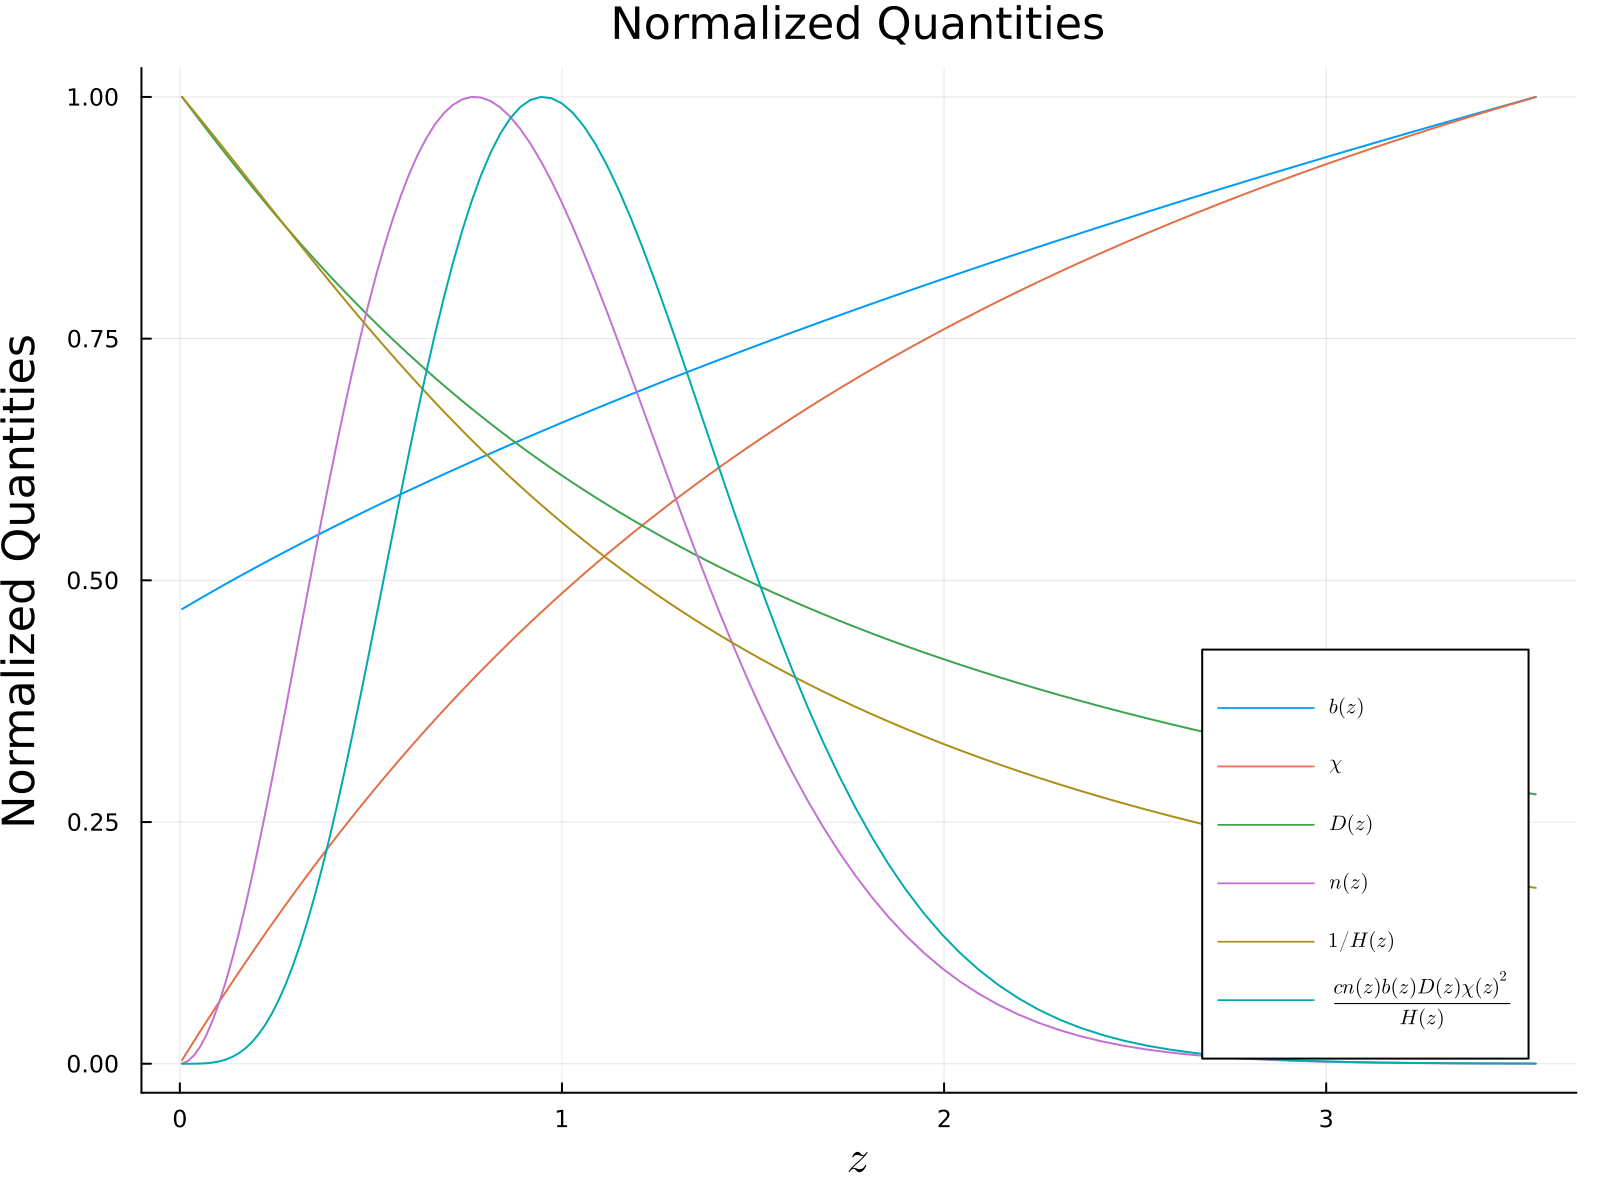

In [21]:
plot(z_range, 
          b_z_array ./ maximum(b_z_array), 
          label=L"$b(z)$", 
          xlabel=L"$z$", 
          ylabel=L"Normalized $b(z)$", 
          title=L"Normalized $b(z)$")
plot!(z_range, 
          x_array ./ maximum(x_array), 
          label=L"$\chi$",
          title = L"Normalized $\chi$",
          xlabel=L"$z$", 
          ylabel=L"Normalized $\chi$")
plot!(z_range, 
          growth_array ./ maximum(growth_array), 
          label=L"$D(z)$", 
          xlabel=L"$z$", 
          ylabel="Normalized quantities", 
          title="Normalized quantities",
          legend=:bottomright, size=(800,600), titlefontsize=15, labelfontsize=15, legendfontsize=15)
plot!(z_range, 
          nz ./ maximum(nz), 
          label=L"$n(z)$", 
          xlabel=L"$z$", 
          ylabel=L"Normalized $n(z)$", 
          title=L"Normalized $n(z)$")
plot!(z_range, 
          inv_Hubble_array ./ maximum(inv_Hubble_array), 
          label=L"$1/H(z)$", 
          xlabel=L"$z$", 
          ylabel=L"Normalized $1/H(z)$", 
          title=L"Normalized $1/H(z)$")
plot!(z_range, 
          prefac ./ maximum(prefac), 
          label=L"$\frac{c n(z) b(z) D(z) \chi(z)^2}{H(z)}$", 
          xlabel=L"$z$", 
          ylabel="Normalized Quantities", 
          title="Normalized Quantities", 
          legend=:bottomright, size=(800,600), titlefontsize=15, labelfontsize=15, legendfontsize=7, dpi=200)

In [53]:
ℓ = Blast.ℓ
#ℓ = LinRange(2, 200, 200)
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
chi = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
zed = z_of_χ.(chi)                                      # array of redshifts corresponding to the comoving distances
n_z = length(zed)
zmin = minimum(z_n5k)                                     # minimum redshift
zmax = maximum(z_n5k)                                     # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^12+1;
#N = 100 #2^(13)+1;                                         # number of integration points

In [54]:
z_cheb_nodes = Blast.get_clencurt_grid_z(zmin, zmax, n_cheb)
chi_interp = DataInterpolations.AkimaInterpolation(chi, z_range, extrapolation=ExtrapolationType.Linear)
chi_cheb = chi_interp.(z_cheb_nodes)
println("Size of chi_cheb: ", size(chi_cheb))
b_interp = DataInterpolations.AkimaInterpolation(b_z_array, z_range, extrapolation=ExtrapolationType.Linear)
b_cheb = b_interp.(z_cheb_nodes)
println("Size of b_cheb: ", size(b_cheb))
D_interp = DataInterpolations.AkimaInterpolation(growth_array, z_range, extrapolation=ExtrapolationType.Linear)
D_cheb = D_interp.(z_cheb_nodes)
println("Size of D_cheb: ", size(D_cheb))
nz_interps = DataInterpolations.AkimaInterpolation(nz, z_range, extrapolation=ExtrapolationType.Linear)
nz_cheb = nz_interps.(z_cheb_nodes)
println("Size of nz_cheb: ", size(nz_cheb))
inv_H_cheb = DataInterpolations.AkimaInterpolation(inv_Hubble_array, z_range, extrapolation=ExtrapolationType.Linear)
inv_H_cheb = inv_H_cheb.(z_cheb_nodes)
println("Size of inv_H_cheb: ", size(inv_H_cheb))
W_vals = zeros(length(z_cheb_nodes))
W_vals .= chi_cheb.^2 .* b_cheb .* D_cheb .* nz_cheb .* inv_H_cheb # dimensions: (n_cheb)
println("Size of W_vals: ", size(W_vals))
#W_coeffs = FastTransforms.chebyshevtransform(W_vals);

Size of chi_cheb: (119,)
Size of b_cheb: (119,)
Size of D_cheb: (119,)
Size of nz_cheb: (119,)
Size of inv_H_cheb: (119,)
Size of W_vals: (119,)


In [55]:
plan = Blast.plan_fft(W_vals)
cheb_coeff = Blast.fast_chebcoefs(W_vals, plan)
true_n_cheb = length(cheb_coeff) 

119

In [56]:
W_tilde = zeros(length(ℓ), length(z_range), length(z_range), true_n_cheb)
for i in eachindex(ℓ)
    W_tilde[i,:,:,:] = Blast.compute_W_tilde(ℓ[i], zmin, zmax, kmin, kmax, z_range, n_cheb-1, N, chi_of_z)
    println("Finished computing W_tilde for ℓ = $(ℓ[i]) at $(Dates.now())")
end

Finished computing W_tilde for ℓ = 2.0 at 2026-06-05T17:14:37.548
Finished computing W_tilde for ℓ = 2.492946194634132 at 2026-06-05T17:14:47.039
Finished computing W_tilde for ℓ = 3.971298300156713 at 2026-06-05T17:14:55.386
Finished computing W_tilde for ℓ = 6.433597361523084 at 2026-06-05T17:15:04.536
Finished computing W_tilde for ℓ = 9.877413386836713 at 2026-06-05T17:15:14.588
Finished computing W_tilde for ℓ = 14.299347745457478 at 2026-06-05T17:15:25.623
Finished computing W_tilde for ℓ = 19.695036522039967 at 2026-06-05T17:15:39.144
Finished computing W_tilde for ℓ = 26.059154823191424 at 2026-06-05T17:15:56.877
Finished computing W_tilde for ℓ = 33.385422032497665 at 2026-06-05T17:16:17.788
Finished computing W_tilde for ℓ = 41.66660800873399 at 2026-06-05T17:16:40.438
Finished computing W_tilde for ℓ = 50.894540221141625 at 2026-06-05T17:17:06.079
Finished computing W_tilde for ℓ = 61.06011181472877 at 2026-06-05T17:17:35.460
Finished computing W_tilde for ℓ = 72.15329059763

In [57]:
println("Size of W_tilde: ", size(W_tilde))

Size of W_tilde: (22, 100, 100, 119)


In [58]:
println(size(W_vals))

(119,)


In [59]:
println("size of cheb_coeff: ", size(cheb_coeff))
println("size of W_tilde: ", size(W_tilde))

size of cheb_coeff: (119,)
size of W_tilde: (22, 100, 100, 119)


In [60]:
@tullio W_final[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff[l];

In [61]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

# println("Dimension of k points: ", size(k)[1])
# println("Dimension of Pklin: ", size(Pklin)[1])
# println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

# plot(k, power_spectrum.(k, 1000.0, 1000.0), 
#      label="Linear P(k)", 
#      xscale=:log10, 
#      yscale=:log10, 
#      title=L"$P(k)$ at $z=0$", titlefontsize=20,
#      xlabel=L"$k \; (h/\mathrm{Mpc})$", 
#      ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
#      labelfontsize=15)
# plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
#       label="Non-linear P(k)", 
#       xscale=:log10, 
#       yscale=:log10,
#       size=(800,600),
#       legendfontsize=10)

In [62]:
Nz = n_chi
k_grid = Blast.get_clencurt_grid(kmin, kmax, Nz)
kp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz) # for the second integral in the double Bessel case
kpp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz); # for the third integral in the double Bessel case

In [63]:
Pk_grid = power_spectrum_nl.(k_grid, first(z), last(z));
Nk = length(k_grid)
w_k = FastTransforms.clenshawcurtisweights(
      FastTransforms.chebyshevmoments1(Float64, Nk)) * (kmax - kmin) / 2
wktot = @. (2/pi) * w_k * k_grid^2 * Pk_grid;

In [64]:
println("size of wktot: ", size(wktot))
println("size of W_final: ", size(W_final))

size of wktot: (100,)
size of W_final: (22, 100, 100)


In [65]:
S_lkk = zeros(Float64, size(W_final, 3), size(W_final, 3), length(ℓ))
@tullio S_lkk[kp, kpp, li] := wktot[k] * W_final[li, k, kp] * W_final[li, kp, kpp];

In [66]:
println("Size of S_l (kp, kpp): ", size(S_lkk))

Size of S_l (kp, kpp): (100, 100, 22)


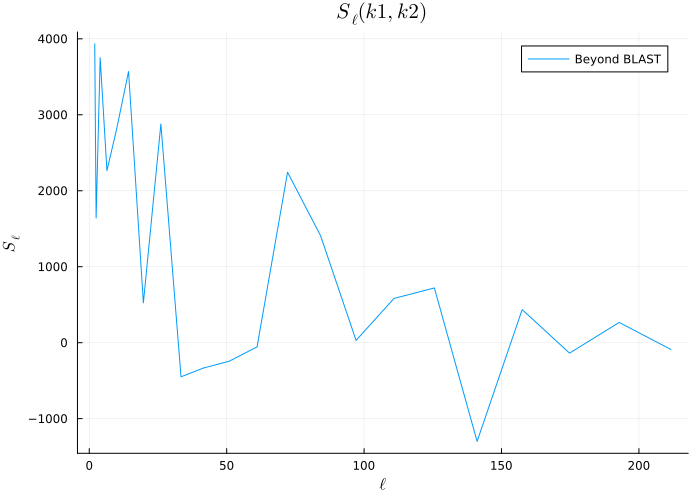

In [67]:
i = 20
j = 2
p = plot(
    ℓ,
    S_lkk[i, j, :],
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"S_\ell",
    title = L"S_\ell(k1, k2)",
    size = (700, 500)
)

In [68]:
S_l = zeros(Float64, length(ℓ))
@tullio S_l[li] := w_k[kp] * w_k[kpp] * S_lkk[kp, kpp, li];

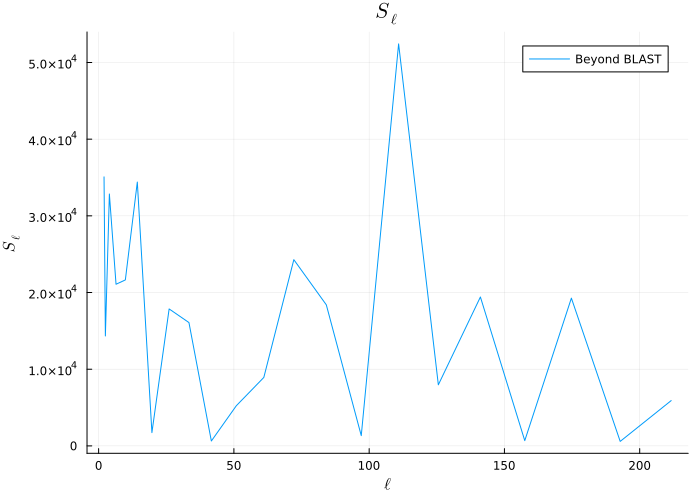

In [69]:
# plot
plot(ℓ, S_l, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell",     size = (700, 500))

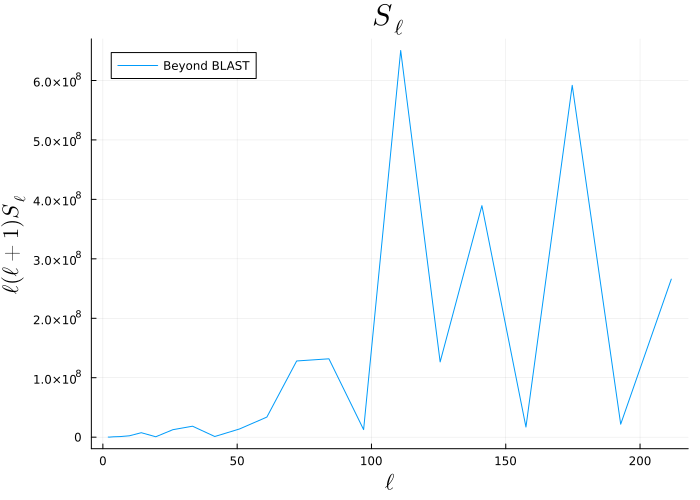

In [70]:
k_plot = ℓ / 14000 # in Mpc-1
p = plot(
    ℓ,
    S_l .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"S_\ell",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
)

In [71]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "runs/run_$timestamp"
# 3. Crea la cartella sul computer
mkpath(output_dir)
println("Cartella creata con successo: ", output_dir)
npzwrite(joinpath(output_dir, "S_l.npy"), S_l)
npzwrite(joinpath(output_dir, "S_lkk.npy"), S_lkk)

Cartella creata con successo: runs/run_2026_06_05_172316
